In [16]:
#Importar las librerias
from pathlib import Path
import sys

# Carpeta raíz del proyecto
project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import os
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from modelos.DBSCANModel import DBSCANModel
from modelos.HDBSCANModel import HDBSCANModel
import numpy as np
import warnings
import joblib

warnings.filterwarnings('ignore')




In [17]:
df_pandas = pd.read_csv("/data_simulada/preprocesado_Polars.csv") # Se importa el CSV

In [18]:
# ================================
# DBSCAN & HDBSCAN
# ================================

##### DBSCAN #####

# 1. Instanciar el modelo
dbscan_pipeline = DBSCANModel(df_pandas, k= 5, min_samples=14)

# 2. Preparar datos (elimina columnas _etiqueta y aplica PCA)
X_pca_df = dbscan_pipeline.prepare_data_for_clustering(n_components=2)

Aplicando PCA para reducir a 2 componentes...
Shape tras PCA: (72000, 2)


[No se ha definido epsilon. Calculando automáticamente...
Epsilon sugerido automáticamente (knee): 0.0419


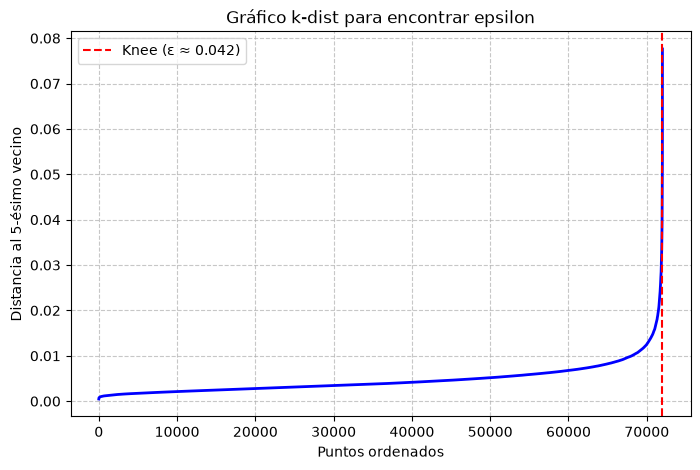

Epsilon asignado automáticamente: 0.0419


,PC1,PC2,cluster
0,0.489022,-0.073410,0
1,0.492106,0.080138,0
2,0.486755,0.035890,0
3,-0.038804,-0.347712,1
4,0.496309,0.044663,0
...,...,...,...
71995,0.060262,0.782503,1
71996,0.009115,0.330207,1
71997,0.009546,0.282379,1
71998,0.025264,0.478155,1


In [19]:
# 3. Ajustar el modelo DBSCAN
# Se usó el siguiente metodo para averiguar que valores de epsilon mejoraban el resultado 
dbscan_pipeline.fit()

In [20]:
# 4. Evaluar
dbscan_pipeline.evaluate()

Silhouette Score: 0.4929


0.492946558273553

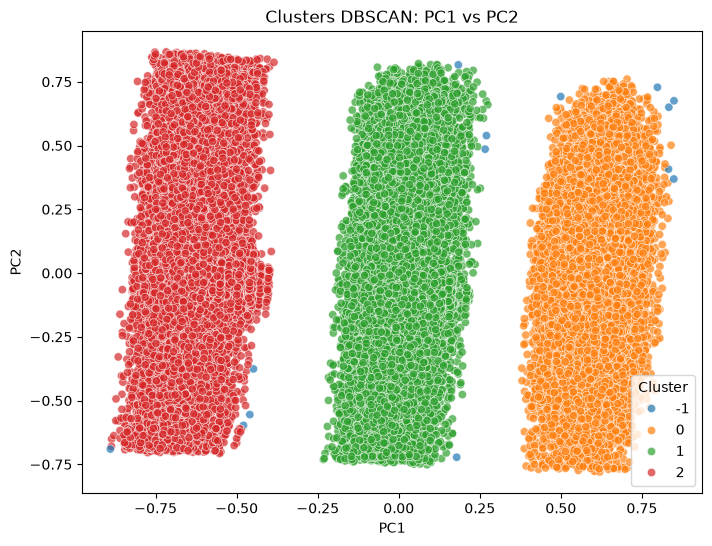

In [21]:
# 5. Visualizar clusters ( PC1 vs. PC2)
dbscan_pipeline.plot_clusters(x_feature='PC1', y_feature='PC2')

In [22]:
joblib.dump(dbscan_pipeline, "../modelos/dbscan_model.pkl")

['../modelos/dbscan_model.pkl']

In [25]:
##### HDBSCAN #####

# 1. Instanciar el modelo
hdbscan_pipeline = HDBSCANModel(df_pandas)

# 2. Preparar datos (elimina columnas '_etiqueta' y aplica PCA)
X_pca_df = hdbscan_pipeline.prepare_data_for_clustering(n_components=3)

Columnas eliminadas: ['inmovilidad_sostenida_etiqueta', 'hipoxia_sostenida_etiqueta', 'frag_sueno_sostenido_etiqueta']
Aplicando PCA para reducir a 3 componentes...
Shape tras PCA: (72000, 3)


In [30]:
# 3. Ajustar HDBSCAN
hdbscan_pipeline.fit(min_cluster_size=50, min_samples=5, metric = 'euclidean')

Clustering completado. Se detectaron 158 clusters.


,PC1,PC2,PC3,cluster
0,-0.568501,-0.304422,-0.919435,61
1,-0.567569,-0.276560,-0.928900,61
2,-0.448934,0.089663,-1.111712,38
3,-0.279243,-0.376362,-0.890445,-1
4,-0.572594,-0.317464,-0.902592,61
...,...,...,...,...
71995,-0.164288,-0.601089,0.030598,123
71996,0.392788,0.012755,-0.210958,-1
71997,0.392068,0.006310,-0.208397,-1
71998,0.265272,-0.406837,0.015376,-1


In [31]:
# 4. Evaluar
hdbscan_pipeline.evaluate()

Silhouette Score (sin ruido): 0.6280


0.6279537428557561

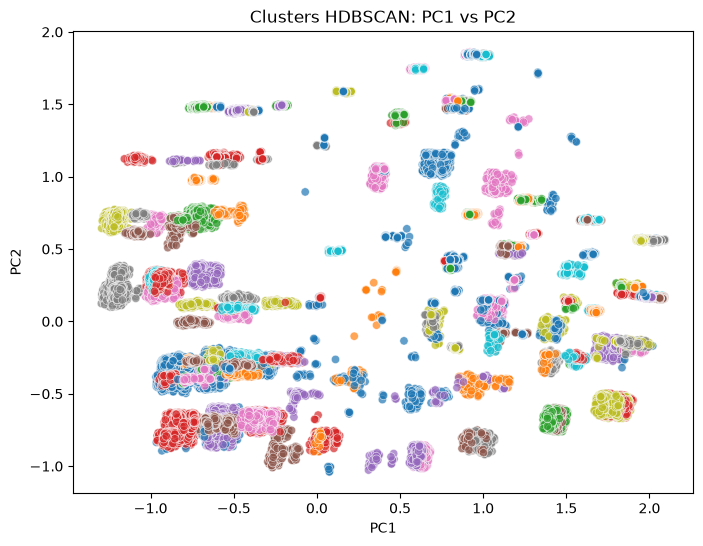

In [32]:
# 5. Visualizar clusters
hdbscan_pipeline.plot_clusters("PC1", "PC2")

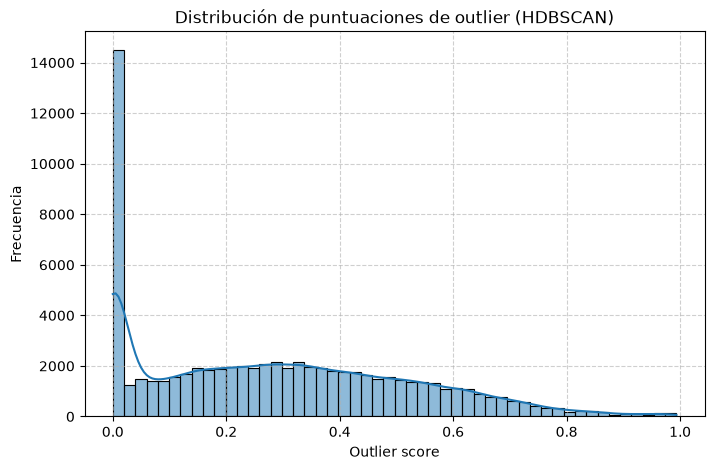

In [33]:
# 6. Visualizar puntuaciones de outlier
hdbscan_pipeline.plot_outlier_scores()

In [34]:
joblib.dump(hdbscan_pipeline, "../modelos/hdbscan_model.pkl")

['../modelos/hdbscan_model.pkl']

In [35]:
#### PRUEBA CON UN SOLO PACIENTE ####

# Filtrar datos del paciente PAC_001
paciente_id = "PAC_001"
df_pac_001 = df_pandas[df_pandas["paciente_id"] == paciente_id].copy()

In [36]:
##### DBSCAN #####

# 1. Instanciar el modelo
dbscan_pac001_pipeline = DBSCANModel(df_pac_001)

# 2. Preparar datos (elimina columnas _etiqueta y aplica PCA)
X_pca_df_pac001 = dbscan_pac001_pipeline.prepare_data_for_clustering(n_components=2)

Aplicando PCA para reducir a 2 componentes...
Shape tras PCA: (18000, 2)


[No se ha definido epsilon. Calculando automáticamente...
Epsilon sugerido automáticamente (knee): 0.0445


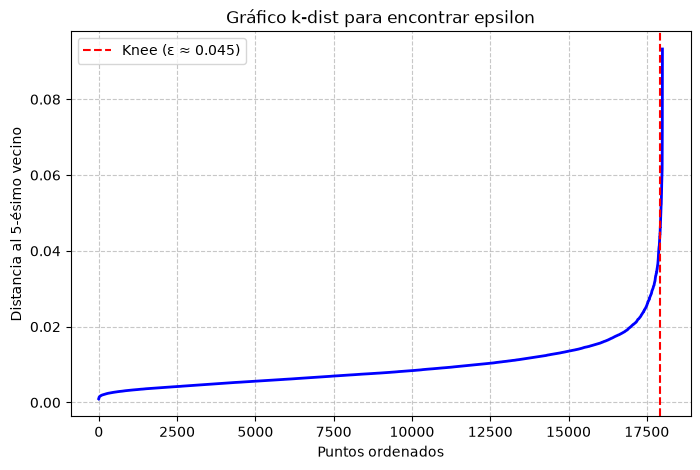

Epsilon asignado automáticamente: 0.0445


,PC1,PC2,cluster
0,0.486224,-0.071952,0
1,0.488700,0.076926,0
2,0.482234,0.026561,0
3,-0.044241,-0.337178,1
4,0.493209,0.045138,0
...,...,...,...
17995,0.022256,0.438192,1
17996,-0.016864,-0.194049,1
17997,0.020460,0.374334,1
17998,0.029157,0.557430,1


In [37]:
# 3. Ajustar el modelo DBSCAN
# Se usó el siguiente metodo para averiguar que valores de epsilon mejoraban el resultado
dbscan_pac001_pipeline.fit()

Silhouette Score: 0.4438


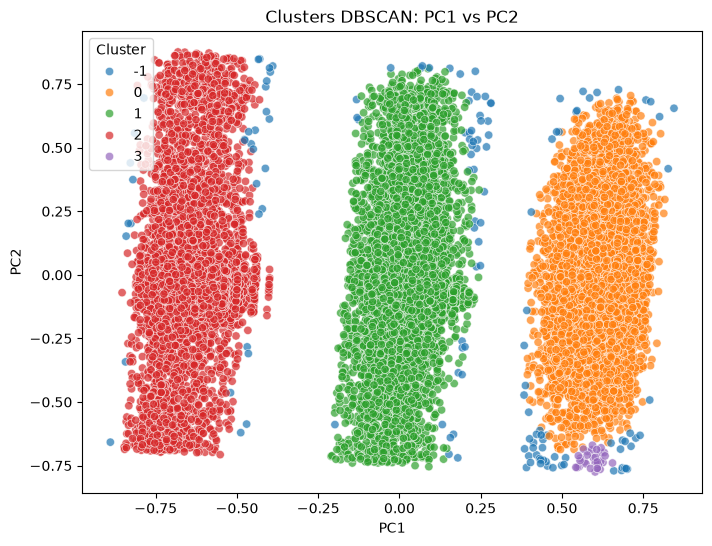

In [38]:
# 4. Evaluar
dbscan_pac001_pipeline.evaluate()

# 5. Visualizar clusters
dbscan_pac001_pipeline.plot_clusters("PC1", "PC2")

In [39]:
joblib.dump(dbscan_pac001_pipeline, "../modelos/dbscan_pac001_pipeline.pkl")

['../modelos/dbscan_pac001_pipeline.pkl']

In [40]:
##### HDBSCAN #####

# 1. Instanciar el modelo
hdbscan_pac001_pipeline = HDBSCANModel(df_pac_001)

# 2. Preparar datos (elimina columnas '_etiqueta' y aplica PCA)
X_pca_df_pac001 = hdbscan_pac001_pipeline.prepare_data_for_clustering(n_components=3)


Columnas eliminadas: ['inmovilidad_sostenida_etiqueta', 'hipoxia_sostenida_etiqueta', 'frag_sueno_sostenido_etiqueta']
Aplicando PCA para reducir a 3 componentes...
Shape tras PCA: (18000, 3)


In [42]:
# 3. Ajustar HDBSCAN
hdbscan_pac001_pipeline.fit(min_cluster_size=50, min_samples=5, metric = 'euclidean')

Clustering completado. Se detectaron 90 clusters.


,PC1,PC2,PC3,cluster
0,-0.560099,-0.288816,-0.916480,66
1,-0.558255,-0.260953,-0.923823,66
2,-0.434176,0.097500,-1.091290,46
3,-0.267628,-0.379106,-0.880383,-1
4,-0.564340,-0.301097,-0.899950,66
...,...,...,...,...
17995,0.390628,-0.497323,0.727452,-1
17996,0.283941,-0.351477,-0.045116,-1
17997,0.266115,-0.384444,0.010782,-1
17998,0.265964,-0.360551,0.003239,-1


Silhouette Score (sin ruido): 0.6712


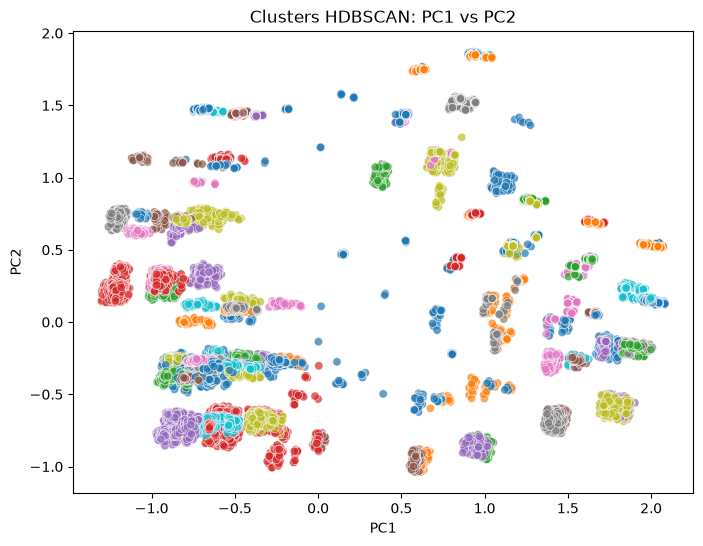

In [43]:
# 4. Evaluar
hdbscan_pac001_pipeline.evaluate()

# 5. Visualizar clusters
hdbscan_pac001_pipeline.plot_clusters("PC1", "PC2")

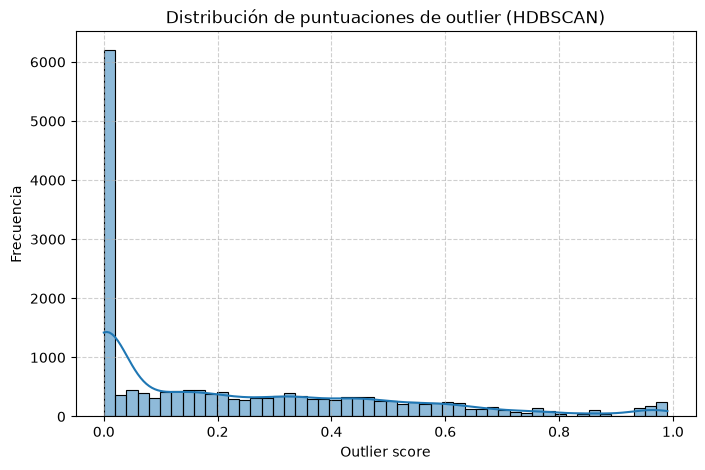

In [44]:
# 6. Visualizar puntuaciones de outlier
hdbscan_pac001_pipeline.plot_outlier_scores()

In [45]:
joblib.dump(hdbscan_pac001_pipeline, "../modelos/hdbscan_pac001_pipeline.pkl")

['../modelos/hdbscan_pac001_pipeline.pkl']